# SPACER Stability Analysis

This notebook summarizes the stability experiments under `stability/`. It follows the metrics produced by `scripts/stability/stability.py`: pairwise Spearman rank correlation, top-K Jaccard overlap, stable core genes, per-gene rank stability, per-gene score stability, and training convergence.

The notebook loads precomputed summaries from `stability/results/{seed,subsample,platform,loo}` when they exist. If a result family is missing but raw run folders are available, it can recompute the same summary tables from the `spacer_score_changes_epoch_*.csv` files.

## Analysis Design

The stability analysis asks whether SPACER recovers the same high-priority genes when the training procedure or training cohort is perturbed. We evaluate four complementary perturbation families:

- `seed`: train on the same data with different random seeds. This isolates stochastic training variation.
- `subsample`: train on random 80% patient/sample subsets. This tests sensitivity to moderate cohort resampling.
- `platform`: train on platform-specific subsets, currently `Visium` and `VisiumHD` in this run. This tests whether high-scoring genes are preserved across spatial technology contexts.
- `loo`: leave one patient/sample out and retrain. This tests whether a single held-out dataset drives the ranking. The raw runs are stored under `stability/patient_holdout/loo_*`, while summary files are written to `stability/results/loo`.

For each run, we load `spacer_score_changes_epoch_*.csv` and use `Difference = SPACER Score After Training - SPACER Score Before Training` as the primary gene-level recruitment score, matching `scripts/stability/stability.py`. By default this notebook uses the last epoch (`EPOCH_SPEC = 'last'`), but the helper functions also support `best` validation-loss epoch or a specific epoch number. Genes are ranked from highest to lowest `Difference` within each run.

We summarize stability with five readouts:

- Pairwise Spearman rank correlation across all genes: high values indicate that the global gene ranking is robust.
- Top-K Jaccard overlap for K = 10, 25, 50, 100, and 200: high values indicate that the most prioritized gene sets are reproducible.
- Stable core genes: genes present in the top-K list for every run within an analysis family.
- Per-gene score and rank coefficient of variation: low CV among high-scoring genes indicates stable magnitude and ordering.
- Training convergence metrics (`Val Loss`, `Val AUROC`): comparable training behavior helps rule out unstable runs as the cause of ranking differences.

The representative stability panel below is intended as a compact figure for reports or slides. It selects evidence that covers both gene-level reproducibility and training behavior: top-K overlap, whole-ranking correlation, stable-core size, and validation AUROC. The top-G sensitivity experiment in `scripts/run_n_genes_sensitivity.sh` is a separate hyperparameter sensitivity analysis; here we keep `n_genes = 500` fixed to isolate seed, cohort, platform, and holdout effects.

In [1]:
from pathlib import Path
import itertools
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path('/project/shared/cli_wang/s439765/spatial_tcr/MIL_TCR')
STABILITY_DIR = ROOT / 'stability'

# These defaults match scripts/stability/stability.py and scripts/run_n_genes_sensitivity.sh.
SCORE_COL = 'Difference'
EPOCH_SPEC = 'last'  # 'last', 'best', or an integer epoch number as a string/int
TOP_K = [10, 25, 50, 100, 200]

# Missing summaries are useful to compute for patient_holdout/loo runs.
RECOMPUTE_MISSING_RESULTS = True
WRITE_DERIVED_RESULTS = True

RUN_SPECS = {
    'seed': {
        'run_root': STABILITY_DIR / 'seed',
        'pattern': 'seed*',
        'results_dir': STABILITY_DIR / 'results' / 'seed',
        'label': 'Random seed',
    },
    'subsample': {
        'run_root': STABILITY_DIR / 'subsample',
        'pattern': 'rep*',
        'results_dir': STABILITY_DIR / 'results' / 'subsample',
        'label': '80% patient subsample',
    },
    'platform': {
        'run_root': STABILITY_DIR / 'platform',
        'pattern': '*',
        'results_dir': STABILITY_DIR / 'results' / 'platform',
        'label': 'Platform split',
    },
    'loo': {
        # stability.py calls this analysis type "loo"; the current raw outputs are under patient_holdout.
        'run_root': STABILITY_DIR / 'patient_holdout',
        'pattern': 'loo_*',
        'results_dir': STABILITY_DIR / 'results' / 'loo',
        'label': 'Leave-one-patient-out',
    },
}

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'ROOT: {ROOT}')
print(f'STABILITY_DIR exists: {STABILITY_DIR.exists()}')

ROOT: /project/shared/cli_wang/s439765/spatial_tcr/MIL_TCR
STABILITY_DIR exists: True


## Helpers

In [2]:
EPOCH_RE = re.compile(r'spacer_score_changes_epoch_(\d+)\.csv$')


def natural_key(value):
    text = str(value)
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r'(\d+)', text)]


def epoch_from_path(path):
    match = EPOCH_RE.search(Path(path).name)
    if match is None:
        raise ValueError(f'Cannot parse epoch from {path}')
    return int(match.group(1))


def discover_runs(group):
    spec = RUN_SPECS[group]
    run_root = spec['run_root']
    if not run_root.exists():
        return {}
    run_dirs = sorted(run_root.glob(spec['pattern']), key=lambda p: natural_key(p.name))
    return {
        run_dir.name: run_dir
        for run_dir in run_dirs
        if run_dir.is_dir() and any(run_dir.glob('spacer_score_changes_epoch_*.csv'))
    }


def choose_score_file(run_dir, epoch_spec=EPOCH_SPEC):
    run_dir = Path(run_dir)
    files = sorted(run_dir.glob('spacer_score_changes_epoch_*.csv'), key=epoch_from_path)
    if not files:
        raise FileNotFoundError(f'No spacer_score_changes_epoch_*.csv files in {run_dir}')

    if str(epoch_spec).lower() == 'last':
        return files[-1]

    if str(epoch_spec).lower() == 'best':
        metrics_path = run_dir / 'training_metrics.csv'
        if metrics_path.exists():
            metrics = pd.read_csv(metrics_path)
            if 'Val Loss' in metrics and 'Epoch' in metrics:
                best_epoch = int(metrics.loc[metrics['Val Loss'].idxmin(), 'Epoch'])
                target = run_dir / f'spacer_score_changes_epoch_{best_epoch}.csv'
                if target.exists():
                    return target
        return files[-1]

    target_epoch = int(epoch_spec)
    target = run_dir / f'spacer_score_changes_epoch_{target_epoch}.csv'
    if not target.exists():
        raise FileNotFoundError(f'Epoch {target_epoch} file not found in {run_dir}')
    return target


def load_score_series(run_dir, epoch_spec=EPOCH_SPEC, score_col=SCORE_COL):
    score_file = choose_score_file(run_dir, epoch_spec=epoch_spec)
    df = pd.read_csv(score_file)
    if 'Gene' not in df:
        raise KeyError(f'Missing Gene column in {score_file}')
    if score_col not in df:
        raise KeyError(f'Missing {score_col!r} in {score_file}. Available: {list(df.columns)}')
    return df.set_index('Gene')[score_col].sort_index()


def jaccard(a, b):
    a = set(a)
    b = set(b)
    return len(a & b) / len(a | b) if (a | b) else np.nan


def summarize_inventory():
    rows = []
    for group, spec in RUN_SPECS.items():
        runs = discover_runs(group)
        result_dir = spec['results_dir']
        for label, run_dir in runs.items():
            score_files = sorted(run_dir.glob('spacer_score_changes_epoch_*.csv'), key=epoch_from_path)
            metrics_path = run_dir / 'training_metrics.csv'
            rows.append({
                'group': group,
                'label': label,
                'run_dir': str(run_dir.relative_to(ROOT)),
                'n_score_files': len(score_files),
                'first_epoch': epoch_from_path(score_files[0]) if score_files else np.nan,
                'last_epoch': epoch_from_path(score_files[-1]) if score_files else np.nan,
                'has_training_metrics': metrics_path.exists(),
                'has_result_summary': (result_dir / 'jaccard_summary.csv').exists(),
            })
    return pd.DataFrame(rows)


def load_training_metrics():
    rows = []
    for group in RUN_SPECS:
        for label, run_dir in discover_runs(group).items():
            metrics_path = run_dir / 'training_metrics.csv'
            if not metrics_path.exists():
                continue
            df = pd.read_csv(metrics_path)
            df['group'] = group
            df['label'] = label
            df['run_dir'] = str(run_dir.relative_to(ROOT))
            rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def load_result_table(group, name):
    path = RUN_SPECS[group]['results_dir'] / name
    if not path.exists():
        return pd.DataFrame()
    if name == 'pairwise_spearman.csv':
        return pd.read_csv(path, index_col=0)
    return pd.read_csv(path)


def load_loo_metadata():
    path = STABILITY_DIR / 'subsets' / 'loo' / 'index.tsv'
    if not path.exists():
        return pd.DataFrame()
    meta = pd.read_csv(path, sep='\t')
    meta['label'] = meta['subset_id'].map(lambda x: f'loo_{int(x):03d}')
    meta['held_out_dataset'] = meta['held_out'].map(lambda p: Path(str(p)).parent.name)
    meta['held_out_platform'] = meta['held_out'].map(lambda p: Path(str(p)).parents[1].name if len(Path(str(p)).parents) > 1 else '')
    return meta

## Recompute missing summaries

In [3]:
def compute_stability(group, top_k=TOP_K, epoch_spec=EPOCH_SPEC, score_col=SCORE_COL):
    runs = discover_runs(group)
    if len(runs) < 2:
        raise ValueError(f'Need at least two runs for {group}; found {len(runs)}')

    scores = {}
    for label, run_dir in runs.items():
        try:
            scores[label] = load_score_series(run_dir, epoch_spec=epoch_spec, score_col=score_col)
        except Exception as exc:
            print(f'Skip {group}/{label}: {exc}')

    if len(scores) < 2:
        raise ValueError(f'Need at least two readable runs for {group}; found {len(scores)}')

    labels = list(scores)
    all_genes = sorted(set().union(*(set(s.index) for s in scores.values())))
    score_df = pd.DataFrame({label: scores[label].reindex(all_genes) for label in labels}, index=all_genes)
    rank_df = score_df.rank(axis=0, ascending=False, na_option='bottom')

    corr_df = rank_df.corr(method='pearson')

    top_sets = {
        label: {k: set(score_df[label].dropna().nlargest(k).index) for k in top_k}
        for label in labels
    }
    jac_rows = []
    for run_i, run_j in itertools.combinations(labels, 2):
        for k in top_k:
            jac_rows.append({
                'run_i': run_i,
                'run_j': run_j,
                'top_k': k,
                'jaccard': jaccard(top_sets[run_i][k], top_sets[run_j][k]),
            })
    jaccard_topk = pd.DataFrame(jac_rows)
    jaccard_summary = (
        jaccard_topk.groupby('top_k')['jaccard']
        .agg(mean='mean', std='std', min='min', max='max')
        .reset_index()
    )

    core_rows = []
    mean_rank = rank_df.mean(axis=1)
    for k in top_k:
        core = set.intersection(*(top_sets[label][k] for label in labels))
        for gene in sorted(core):
            core_rows.append({'top_k': k, 'gene': gene, 'mean_rank': mean_rank.loc[gene]})
    stable_core = pd.DataFrame(core_rows).sort_values(['top_k', 'mean_rank']) if core_rows else pd.DataFrame(columns=['top_k', 'gene', 'mean_rank'])

    rank_stats = rank_df.copy()
    rank_stats['mean_rank'] = rank_stats[labels].mean(axis=1)
    rank_stats['std_rank'] = rank_stats[labels].std(axis=1)
    rank_stats['cv_rank'] = rank_stats['std_rank'] / rank_stats['mean_rank']
    rank_stats = rank_stats.sort_values('mean_rank')

    score_stats = score_df.copy()
    score_stats['mean_score'] = score_stats[labels].mean(axis=1)
    score_stats['std_score'] = score_stats[labels].std(axis=1)
    score_stats['cv_score'] = score_stats['std_score'] / score_stats['mean_score'].abs().replace(0, np.nan)
    score_stats = score_stats.sort_values('mean_score', ascending=False)

    return {
        'pairwise_spearman': corr_df,
        'jaccard_topk': jaccard_topk,
        'jaccard_summary': jaccard_summary,
        'stable_core_topK': stable_core,
        'per_gene_rank_stats': rank_stats,
        'per_gene_score_stats': score_stats,
    }


def write_stability_results(group, result):
    out_dir = RUN_SPECS[group]['results_dir']
    out_dir.mkdir(parents=True, exist_ok=True)
    result['pairwise_spearman'].to_csv(out_dir / 'pairwise_spearman.csv')
    result['jaccard_topk'].to_csv(out_dir / 'jaccard_topk.csv', index=False)
    result['jaccard_summary'].to_csv(out_dir / 'jaccard_summary.csv', index=False)
    result['stable_core_topK'].to_csv(out_dir / 'stable_core_topK.csv', index=False)
    result['per_gene_rank_stats'].to_csv(out_dir / 'per_gene_rank_stats.csv')
    result['per_gene_score_stats'].to_csv(out_dir / 'per_gene_score_stats.csv')
    return out_dir


computed_results = {}
if RECOMPUTE_MISSING_RESULTS:
    for group, spec in RUN_SPECS.items():
        summary_path = spec['results_dir'] / 'jaccard_summary.csv'
        if summary_path.exists():
            continue
        if len(discover_runs(group)) < 2:
            continue
        print(f'Recomputing missing summary for {group} from raw run folders...')
        computed_results[group] = compute_stability(group)
        if WRITE_DERIVED_RESULTS:
            out_dir = write_stability_results(group, computed_results[group])
            print(f'  wrote {out_dir.relative_to(ROOT)}')

computed_results.keys()

Recomputing missing summary for loo from raw run folders...
  wrote stability/results/loo


dict_keys(['loo'])

## Run inventory

In [4]:
inventory = summarize_inventory()
display(
    inventory.groupby('group')
    .agg(
        n_runs=('label', 'count'),
        min_epoch=('last_epoch', 'min'),
        max_epoch=('last_epoch', 'max'),
        runs_with_training_metrics=('has_training_metrics', 'sum'),
        has_result_summary=('has_result_summary', 'max'),
    )
    .reset_index()
)

inventory.sort_values(['group', 'label']).head(20)

,group,n_runs,min_epoch,max_epoch,runs_with_training_metrics,has_result_summary
0,loo,28,10,10,28,True
1,platform,2,10,10,2,True
2,seed,10,10,10,10,True
3,subsample,10,10,10,10,True


,group,label,run_dir,n_score_files,first_epoch,last_epoch,has_training_metrics,has_result_summary
22,loo,loo_000,stability/patient_holdout/loo_000,10,1,10,True,True
23,loo,loo_001,stability/patient_holdout/loo_001,10,1,10,True,True
24,loo,loo_002,stability/patient_holdout/loo_002,10,1,10,True,True
25,loo,loo_003,stability/patient_holdout/loo_003,10,1,10,True,True
26,loo,loo_004,stability/patient_holdout/loo_004,10,1,10,True,True
27,loo,loo_005,stability/patient_holdout/loo_005,10,1,10,True,True
28,loo,loo_006,stability/patient_holdout/loo_006,10,1,10,True,True
29,loo,loo_007,stability/patient_holdout/loo_007,10,1,10,True,True
30,loo,loo_008,stability/patient_holdout/loo_008,10,1,10,True,True
31,loo,loo_009,stability/patient_holdout/loo_009,10,1,10,True,True


In [5]:
loo_meta = load_loo_metadata()
if not loo_meta.empty:
    display(loo_meta[['label', 'held_out_platform', 'held_out_dataset', 'held_out']].head(10))

,label,held_out_platform,held_out_dataset,held_out
0,loo_000,Visium,HumanOvarianCancer,/project/shared/cli_wang/spatial_TCR/data/trai...
1,loo_001,Visium,HumanOvarianCancerWholeTranscriptome,/project/shared/cli_wang/spatial_TCR/data/trai...
2,loo_002,Visium,HumanColorectalCancerWholeTranscriptome,/project/shared/cli_wang/spatial_TCR/data/trai...
3,loo_003,Visium,HumanOvarianCancerFFPE,/project/shared/cli_wang/spatial_TCR/data/trai...
4,loo_004,Visium,HumanLungCancer,/project/shared/cli_wang/spatial_TCR/data/trai...
5,loo_005,Visium,HumanBreastCancerDuctalCarcinoma,/project/shared/cli_wang/spatial_TCR/data/trai...
6,loo_006,Visium,HumanProstateCancerAdenocarcinomaFFPE,/project/shared/cli_wang/spatial_TCR/data/trai...
7,loo_007,Visium,HumanBreastCancerA2,/project/shared/cli_wang/spatial_TCR/data/trai...
8,loo_008,Visium,InvasiveDuctalCarcinoma,/project/shared/cli_wang/spatial_TCR/data/trai...
9,loo_009,Visium,HumanBreastCancer,/project/shared/cli_wang/spatial_TCR/data/trai...


## Training convergence

In [6]:
metrics = load_training_metrics()
if metrics.empty:
    print('No training_metrics.csv files found.')
else:
    summary_rows = []
    for (group, label), df in metrics.groupby(['group', 'label']):
        row = {'group': group, 'label': label, 'n_epochs': len(df)}
        if 'Val Loss' in df:
            row['best_val_loss'] = df['Val Loss'].min()
            row['best_loss_epoch'] = int(df.loc[df['Val Loss'].idxmin(), 'Epoch'])
            row['last_val_loss'] = df['Val Loss'].iloc[-1]
        if 'Val AUROC' in df:
            row['best_val_auroc'] = df['Val AUROC'].max()
            row['best_auroc_epoch'] = int(df.loc[df['Val AUROC'].idxmax(), 'Epoch'])
            row['last_val_auroc'] = df['Val AUROC'].iloc[-1]
        summary_rows.append(row)
    training_summary = pd.DataFrame(summary_rows)
    display(training_summary.groupby('group').agg({
        'label': 'count',
        'n_epochs': ['mean', 'min', 'max'],
        'best_val_loss': ['mean', 'std'],
        'best_val_auroc': ['mean', 'std'],
    }).round(4))
    display(training_summary.sort_values(['group', 'best_val_auroc'], ascending=[True, False]).head(12))

label n_epochs         best_val_loss         best_val_auroc        
          count     mean min max          mean     std           mean     std
group                                                                        
loo          28     10.0  10  10        0.6507  0.0029         0.7311  0.0125
platform      2     10.0  10  10        0.6411  0.0152         0.7516  0.0359
seed         10     10.0  10  10        0.6515  0.0013         0.7336  0.0065
subsample    10     10.0  10  10        0.6420  0.0068         0.7426  0.0257

,group,label,n_epochs,best_val_loss,best_loss_epoch,last_val_loss,best_val_auroc,best_auroc_epoch,last_val_auroc
25,loo,loo_025,10,0.642768,5,0.645077,0.754873,3,0.703947
20,loo,loo_020,10,0.643579,3,0.647377,0.749037,1,0.733284
3,loo,loo_003,10,0.650337,2,0.651936,0.748582,1,0.735789
5,loo,loo_005,10,0.649965,2,0.652085,0.747562,1,0.699520
1,loo,loo_001,10,0.652226,6,0.655850,0.747498,6,0.717601
10,loo,loo_010,10,0.651541,6,0.655185,0.747091,3,0.710184
11,loo,loo_011,10,0.649905,6,0.652242,0.744652,5,0.702724
12,loo,loo_012,10,0.652256,5,0.662378,0.738753,9,0.694927
22,loo,loo_022,10,0.646350,6,0.657165,0.737545,10,0.737545
14,loo,loo_014,10,0.652014,8,0.654900,0.736611,10,0.736611


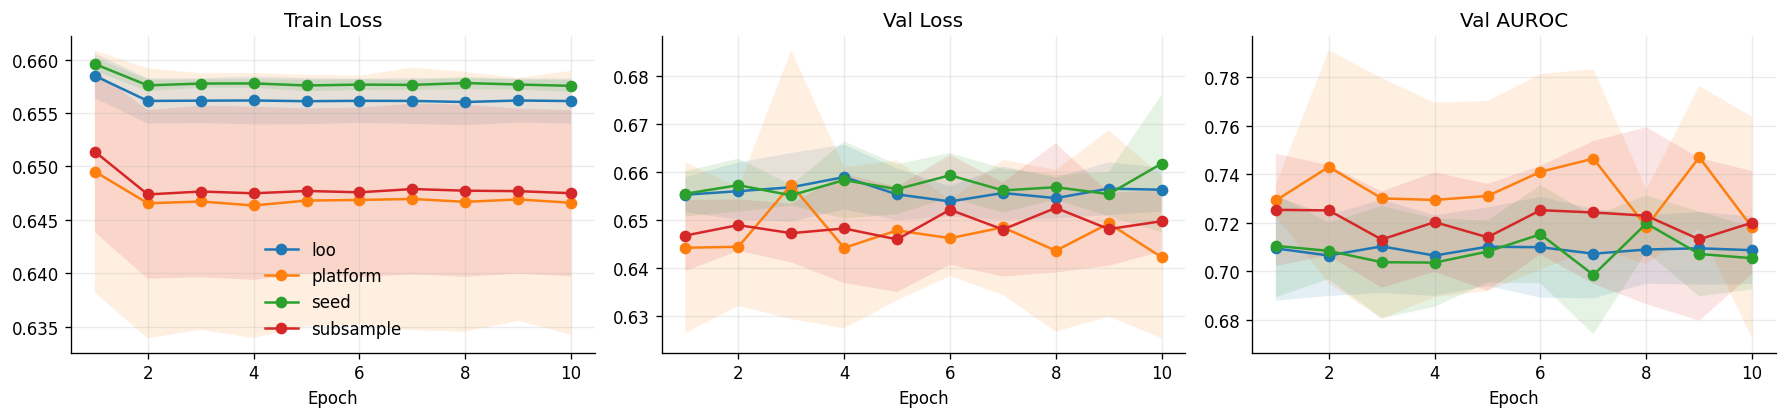

In [7]:
if not metrics.empty:
    cols = [col for col in ['Train Loss', 'Val Loss', 'Val AUROC'] if col in metrics.columns]
    fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 3.6), squeeze=False)
    for ax, col in zip(axes.ravel(), cols):
        grouped = metrics.groupby(['group', 'Epoch'])[col].agg(['mean', 'std']).reset_index()
        for group, gdf in grouped.groupby('group'):
            ax.plot(gdf['Epoch'], gdf['mean'], marker='o', linewidth=1.5, label=group)
            if gdf['std'].notna().any():
                ax.fill_between(gdf['Epoch'], gdf['mean'] - gdf['std'], gdf['mean'] + gdf['std'], alpha=0.12)
        ax.set_title(col)
        ax.set_xlabel('Epoch')
        ax.grid(alpha=0.25)
    axes.ravel()[0].legend(frameon=False)
    fig.tight_layout()

## Top-K set stability

In [8]:
jaccard_summaries = []
for group in RUN_SPECS:
    df = load_result_table(group, 'jaccard_summary.csv')
    if df.empty:
        continue
    df['group'] = group
    df['analysis'] = RUN_SPECS[group]['label']
    jaccard_summaries.append(df)

jaccard_summary = pd.concat(jaccard_summaries, ignore_index=True) if jaccard_summaries else pd.DataFrame()
display(jaccard_summary.sort_values(['group', 'top_k']).round(4))

,top_k,mean,std,min,max,group,analysis
15,10,0.7160,0.2139,0.0000,1.0000,loo,Leave-one-patient-out
16,25,0.7949,0.2119,0.0638,1.0000,loo,Leave-one-patient-out
17,50,0.5921,0.1245,0.1111,0.7544,loo,Leave-one-patient-out
18,100,0.4900,0.0739,0.2048,0.6260,loo,Leave-one-patient-out
19,200,0.4978,0.0477,0.3245,0.6194,loo,Leave-one-patient-out
10,10,0.5385,NaN,0.5385,0.5385,platform,Platform split
11,25,1.0000,NaN,1.0000,1.0000,platform,Platform split
12,50,0.5625,NaN,0.5625,0.5625,platform,Platform split
13,100,0.3514,NaN,0.3514,0.3514,platform,Platform split
14,200,0.2121,NaN,0.2121,0.2121,platform,Platform split


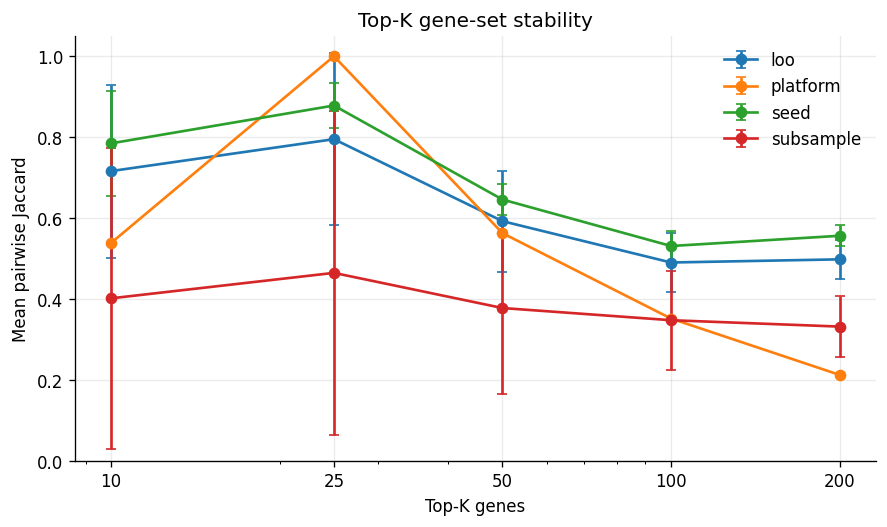

In [9]:
if not jaccard_summary.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for group, gdf in jaccard_summary.groupby('group'):
        gdf = gdf.sort_values('top_k')
        yerr = gdf['std'].fillna(0)
        ax.errorbar(gdf['top_k'], gdf['mean'], yerr=yerr, marker='o', capsize=3, linewidth=1.6, label=group)
    ax.set_xscale('log')
    ax.set_xticks(sorted(jaccard_summary['top_k'].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Top-K genes')
    ax.set_ylabel('Mean pairwise Jaccard')
    ax.set_title('Top-K gene-set stability')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

In [10]:
if not jaccard_summary.empty:
    pivot = jaccard_summary.pivot(index='group', columns='top_k', values='mean')
    display(pivot.round(3).style.background_gradient(cmap='Blues', vmin=0, vmax=1))

top_k,10,25,50,100,200
group,,,,,
loo,0.716000,0.795000,0.592000,0.490000,0.498000
platform,0.538000,1.000000,0.562000,0.351000,0.212000
seed,0.785000,0.878000,0.646000,0.531000,0.556000
subsample,0.401000,0.464000,0.377000,0.347000,0.332000


## Pairwise rank correlation

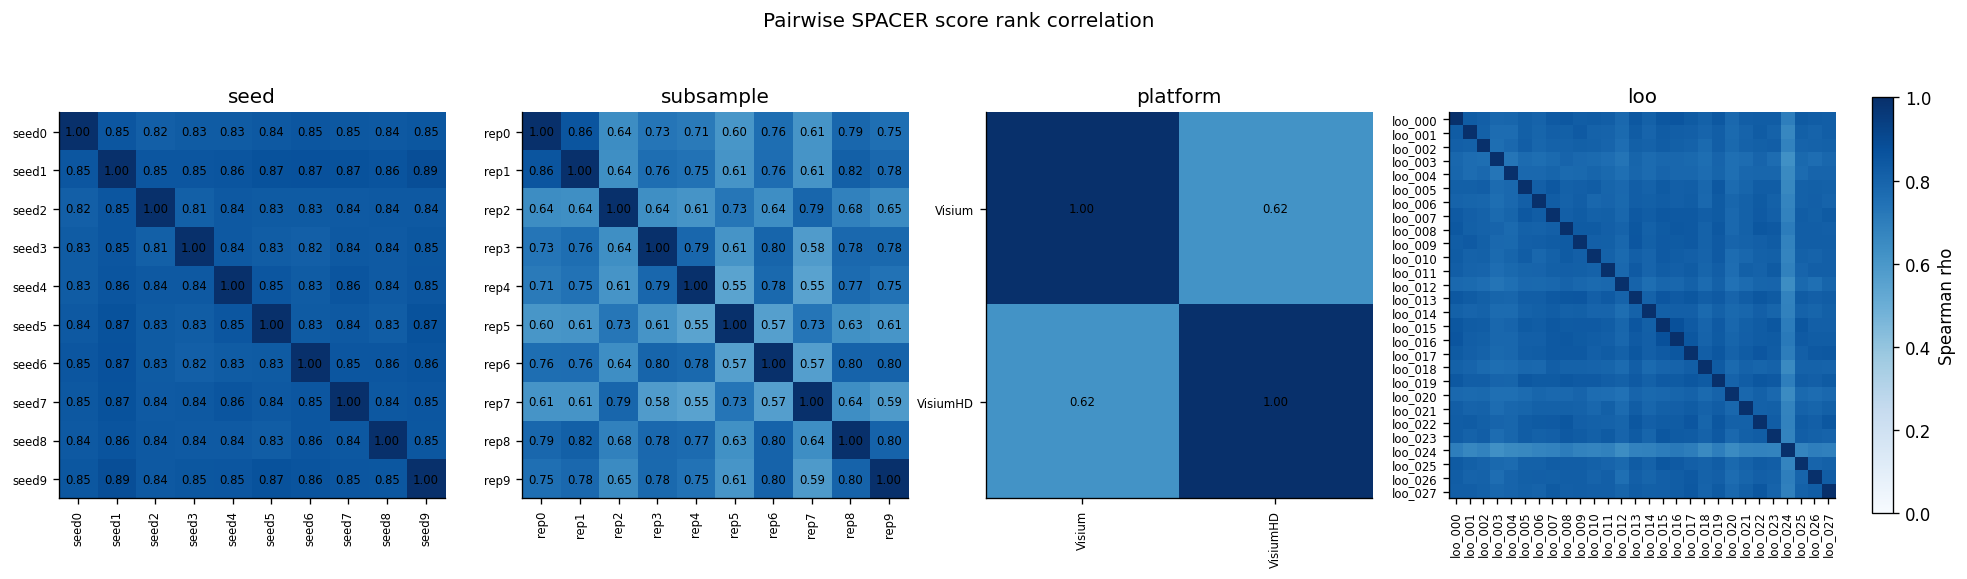

In [11]:
def plot_corr_heatmap(corr, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(corr.values, vmin=0, vmax=1, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(corr.index, fontsize=7)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            if len(corr.index) <= 12:
                ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
    return im


corr_tables = {group: load_result_table(group, 'pairwise_spearman.csv') for group in RUN_SPECS}
corr_tables = {group: corr for group, corr in corr_tables.items() if not corr.empty}

if corr_tables:
    n = len(corr_tables)
    fig, axes = plt.subplots(1, n, figsize=(max(5 * n, 5), 4.5), squeeze=False)
    last_im = None
    for ax, (group, corr) in zip(axes.ravel(), corr_tables.items()):
        last_im = plot_corr_heatmap(corr, group, ax=ax)
    fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label='Spearman rho')
    fig.suptitle('Pairwise SPACER score rank correlation', y=1.04)
else:
    print('No pairwise_spearman.csv files found.')

In [12]:
corr_summary = []
for group, corr in corr_tables.items():
    arr = corr.to_numpy(dtype=float)
    off_diag = arr[np.triu_indices_from(arr, k=1)]
    corr_summary.append({
        'group': group,
        'n_runs': corr.shape[0],
        'mean_spearman': np.nanmean(off_diag),
        'std_spearman': np.nanstd(off_diag),
        'min_spearman': np.nanmin(off_diag),
        'max_spearman': np.nanmax(off_diag),
    })

corr_summary = pd.DataFrame(corr_summary)
display(corr_summary.round(4))

,group,n_runs,mean_spearman,std_spearman,min_spearman,max_spearman
0,seed,10,0.8460,0.0149,0.8149,0.8852
1,subsample,10,0.6977,0.0877,0.5506,0.8573
2,platform,2,0.6178,0.0000,0.6178,0.6178
3,loo,28,0.8003,0.0411,0.6318,0.8753


## Stable core genes

In [13]:
core_tables = []
for group in RUN_SPECS:
    df = load_result_table(group, 'stable_core_topK.csv')
    if df.empty:
        continue
    df['group'] = group
    core_tables.append(df)

stable_core = pd.concat(core_tables, ignore_index=True) if core_tables else pd.DataFrame()
if stable_core.empty:
    print('No stable_core_topK.csv files found.')
else:
    core_counts = stable_core.groupby(['group', 'top_k']).size().reset_index(name='n_core_genes')
    core_counts['pct_of_k'] = 100 * core_counts['n_core_genes'] / core_counts['top_k']
    display(core_counts.sort_values(['group', 'top_k']).round(2))
    display(stable_core[stable_core['top_k'].eq(100)].sort_values(['group', 'mean_rank']).head(50))

,group,top_k,n_core_genes,pct_of_k
0,loo,25,3,12.0
1,loo,50,3,6.0
2,loo,100,6,6.0
3,loo,200,18,9.0
4,platform,10,7,70.0
5,platform,25,25,100.0
6,platform,50,36,72.0
7,platform,100,52,52.0
8,platform,200,70,35.0
9,seed,10,7,70.0


,top_k,gene,mean_rank,group
401,100,FGL1,9.178571,loo
402,100,CD274,9.357143,loo
403,100,GUCY2C,18.000000,loo
404,100,ZFAS1,33.964286,loo
405,100,TAP2,46.000000,loo
406,100,HLA-DOB,51.642857,loo
273,100,BCL2,1.000000,platform
274,100,MAGEA10,2.500000,platform
275,100,AFP,3.500000,platform
276,100,MAGEA4,4.000000,platform


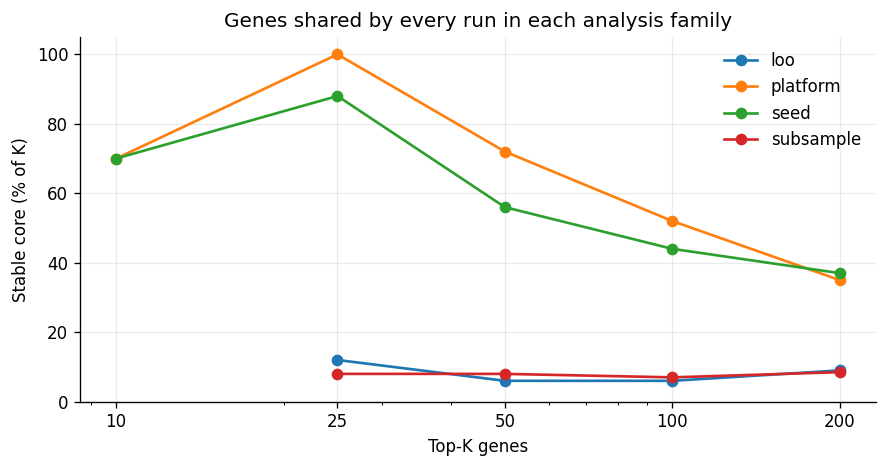

In [14]:
if not stable_core.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4))
    for group, gdf in core_counts.groupby('group'):
        gdf = gdf.sort_values('top_k')
        ax.plot(gdf['top_k'], gdf['pct_of_k'], marker='o', linewidth=1.6, label=group)
    ax.set_xscale('log')
    ax.set_xticks(sorted(core_counts['top_k'].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_xlabel('Top-K genes')
    ax.set_ylabel('Stable core (% of K)')
    ax.set_ylim(0, 105)
    ax.set_title('Genes shared by every run in each analysis family')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

## Per-gene score and rank stability

In [15]:
def top_stable_genes(group, top_n=25, score_pool=100, rank_pool=100):
    score_stats = load_result_table(group, 'per_gene_score_stats.csv')
    rank_stats = load_result_table(group, 'per_gene_rank_stats.csv')
    if score_stats.empty or rank_stats.empty:
        return pd.DataFrame()

    score_stats = score_stats.rename(columns={score_stats.columns[0]: 'Gene'}) if score_stats.columns[0] != 'Gene' else score_stats
    rank_stats = rank_stats.rename(columns={rank_stats.columns[0]: 'Gene'}) if rank_stats.columns[0] != 'Gene' else rank_stats

    high_score_stable = (
        score_stats.head(score_pool)
        .nsmallest(top_n, 'cv_score')
        [['Gene', 'mean_score', 'std_score', 'cv_score']]
    )
    high_rank_stable = (
        rank_stats.head(rank_pool)
        .nsmallest(top_n, 'cv_rank')
        [['Gene', 'mean_rank', 'std_rank', 'cv_rank']]
    )
    out = high_score_stable.merge(high_rank_stable, on='Gene', how='outer')
    out.insert(0, 'group', group)
    return out.sort_values(['cv_score', 'cv_rank'], na_position='last')


stable_gene_tables = [top_stable_genes(group) for group in RUN_SPECS]
stable_gene_tables = [df for df in stable_gene_tables if not df.empty]
stable_genes = pd.concat(stable_gene_tables, ignore_index=True) if stable_gene_tables else pd.DataFrame()
display(stable_genes.round(4).head(80))

,group,Gene,mean_score,std_score,cv_score,mean_rank,std_rank,cv_rank
0,seed,MAGEA4,12.3237,0.0866,0.0070,NaN,NaN,NaN
1,seed,MAGEA10,12.3605,0.0875,0.0071,NaN,NaN,NaN
2,seed,OR2H1,12.3802,0.1214,0.0098,NaN,NaN,NaN
3,seed,SLC45A2,12.0998,0.1311,0.0108,6.9,1.1005,0.1595
4,seed,AFP,12.3385,0.1482,0.0120,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
75,platform,MAGEA10,12.2340,0.0262,0.0021,NaN,NaN,NaN
76,platform,AFP,12.2266,0.0424,0.0035,NaN,NaN,NaN
77,platform,OR5V1,12.0248,0.0442,0.0037,9.0,1.4142,0.1571
78,platform,MAGEA4,12.1691,0.0552,0.0045,NaN,NaN,NaN


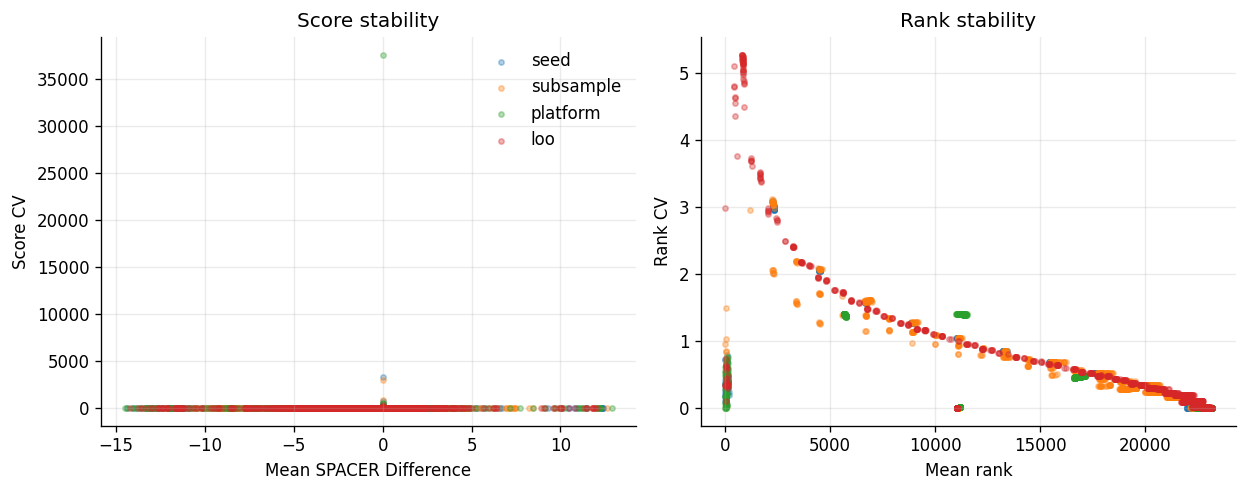

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
plotted = False
for group in RUN_SPECS:
    score_stats = load_result_table(group, 'per_gene_score_stats.csv')
    rank_stats = load_result_table(group, 'per_gene_rank_stats.csv')
    if score_stats.empty or rank_stats.empty:
        continue
    score_stats = score_stats.rename(columns={score_stats.columns[0]: 'Gene'}) if score_stats.columns[0] != 'Gene' else score_stats
    rank_stats = rank_stats.rename(columns={rank_stats.columns[0]: 'Gene'}) if rank_stats.columns[0] != 'Gene' else rank_stats
    axes[0].scatter(score_stats['mean_score'], score_stats['cv_score'], s=10, alpha=0.35, label=group)
    axes[1].scatter(rank_stats['mean_rank'], rank_stats['cv_rank'], s=10, alpha=0.35, label=group)
    plotted = True

if plotted:
    axes[0].set_xlabel('Mean SPACER Difference')
    axes[0].set_ylabel('Score CV')
    axes[0].set_title('Score stability')
    axes[1].set_xlabel('Mean rank')
    axes[1].set_ylabel('Rank CV')
    axes[1].set_title('Rank stability')
    for ax in axes:
        ax.grid(alpha=0.25)
    axes[0].legend(frameon=False)
    fig.tight_layout()
else:
    plt.close(fig)
    print('No per-gene stability tables found.')

## Cross-analysis consensus

In [17]:
consensus_k = 100
core_by_group = {}
for group in RUN_SPECS:
    df = load_result_table(group, 'stable_core_topK.csv')
    if df.empty:
        continue
    core_by_group[group] = set(df.loc[df['top_k'].eq(consensus_k), 'gene'])

if len(core_by_group) >= 2:
    gene_rows = []
    all_core_genes = sorted(set().union(*core_by_group.values()))
    for gene in all_core_genes:
        present_groups = [group for group, genes in core_by_group.items() if gene in genes]
        gene_rows.append({
            'gene': gene,
            'n_groups': len(present_groups),
            'groups': ', '.join(present_groups),
        })
    consensus = pd.DataFrame(gene_rows).sort_values(['n_groups', 'gene'], ascending=[False, True])
    display(consensus.head(50))

    shared_all = set.intersection(*core_by_group.values())
    print(f'Genes in stable Top-{consensus_k} core for every available analysis family: {len(shared_all)}')
    display(pd.DataFrame({'gene': sorted(shared_all)}).head(100))
else:
    print('Need stable-core tables for at least two groups to compute cross-analysis consensus.')

,gene,n_groups,groups
7,CD274,4,"seed, subsample, platform, loo"
20,FGL1,4,"seed, subsample, platform, loo"
23,GUCY2C,4,"seed, subsample, platform, loo"
3,BCL2,3,"seed, subsample, platform"
0,AFP,2,"seed, platform"
1,ANKRD10,2,"seed, platform"
2,AURKA,2,"seed, platform"
4,BIRC5,2,"seed, platform"
5,C1orf198,2,"seed, platform"
10,CDK6,2,"seed, platform"


Genes in stable Top-100 core for every available analysis family: 3


,gene
0,CD274
1,FGL1
2,GUCY2C


## Representative Stability Evidence

This section collects a small set of high-signal results to demonstrate model stability without showing every diagnostic plot. The summary table reports, for each analysis family, the mean top-100 Jaccard overlap, mean off-diagonal Spearman correlation, and the number of genes that remain in the top-100 list for every run. The figure then shows four representative views: top-K Jaccard curves, mean Spearman correlation, stable-core percentage, and validation AUROC distributions.

In [ ]:

REPRESENTATIVE_TOP_K = 100
EXPORT_DIR = STABILITY_DIR / 'results' / 'notebook_exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _nearest_top_k(summary, target=REPRESENTATIVE_TOP_K):
    if summary.empty or 'top_k' not in summary:
        return None
    idx = (summary['top_k'] - target).abs().idxmin()
    return summary.loc[idx]


# Load the compact tables needed for this section directly from disk so the
# panel can be rerun even if earlier plotting cells were skipped.
representative_jaccard_tables = []
representative_core_tables = []
for group in RUN_SPECS:
    js = load_result_table(group, 'jaccard_summary.csv')
    if not js.empty:
        js = js.copy()
        js['group'] = group
        representative_jaccard_tables.append(js)

    core = load_result_table(group, 'stable_core_topK.csv')
    if not core.empty:
        core = core.copy()
        core['group'] = group
        representative_core_tables.append(core)

representative_jaccard_summary = (
    pd.concat(representative_jaccard_tables, ignore_index=True)
    if representative_jaccard_tables else pd.DataFrame()
)
representative_stable_core = (
    pd.concat(representative_core_tables, ignore_index=True)
    if representative_core_tables else pd.DataFrame()
)
representative_metrics = metrics if 'metrics' in globals() else load_training_metrics()

representative_rows = []
for group, spec in RUN_SPECS.items():
    runs = discover_runs(group)
    js = load_result_table(group, 'jaccard_summary.csv')
    corr = load_result_table(group, 'pairwise_spearman.csv')
    core = load_result_table(group, 'stable_core_topK.csv')

    row = {
        'group': group,
        'analysis': spec['label'],
        'n_runs': len(runs),
        'reported_top_k': np.nan,
        'mean_jaccard': np.nan,
        'std_jaccard': np.nan,
        'mean_spearman': np.nan,
        'std_spearman': np.nan,
        'stable_core_genes': np.nan,
        'stable_core_pct_of_k': np.nan,
    }

    jk = _nearest_top_k(js)
    if jk is not None:
        row['reported_top_k'] = int(jk['top_k'])
        row['mean_jaccard'] = jk['mean']
        row['std_jaccard'] = jk.get('std', np.nan)

    if not corr.empty:
        arr = corr.to_numpy(dtype=float)
        off_diag = arr[np.triu_indices_from(arr, k=1)]
        row['mean_spearman'] = np.nanmean(off_diag)
        row['std_spearman'] = np.nanstd(off_diag)

    if not core.empty and not pd.isna(row['reported_top_k']):
        k = int(row['reported_top_k'])
        core_at_k = core.loc[core['top_k'].eq(k)]
        row['stable_core_genes'] = len(core_at_k)
        row['stable_core_pct_of_k'] = 100 * len(core_at_k) / k

    representative_rows.append(row)

representative_summary = pd.DataFrame(representative_rows)
representative_summary.to_csv(EXPORT_DIR / 'representative_stability_summary.csv', index=False)
display(representative_summary.round(4))

if 'consensus' in globals() and not consensus.empty:
    display(consensus.head(15))

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))
axes = axes.ravel()

# A. Top-K gene-set overlap
ax = axes[0]
if not representative_jaccard_summary.empty:
    for group, gdf in representative_jaccard_summary.groupby('group'):
        gdf = gdf.sort_values('top_k')
        ax.errorbar(
            gdf['top_k'], gdf['mean'], yerr=gdf['std'].fillna(0),
            marker='o', capsize=3, linewidth=1.6, label=group,
        )
    ax.set_xscale('log')
    ax.set_xticks(sorted(representative_jaccard_summary['top_k'].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False, fontsize=8)
else:
    ax.text(0.5, 0.5, 'No Jaccard summaries', ha='center', va='center')
ax.set_title('A. Top-K gene-set overlap')
ax.set_xlabel('Top-K genes')
ax.set_ylabel('Mean Jaccard')
ax.grid(alpha=0.25)

# B. Whole-ranking reproducibility
ax = axes[1]
plot_df = representative_summary.dropna(subset=['mean_spearman']).copy()
if not plot_df.empty:
    x = np.arange(len(plot_df))
    ax.bar(x, plot_df['mean_spearman'], yerr=plot_df['std_spearman'].fillna(0), capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['group'], rotation=30, ha='right')
    ax.set_ylim(0, 1.05)
else:
    ax.text(0.5, 0.5, 'No Spearman summaries', ha='center', va='center')
ax.set_title('B. Pairwise rank correlation')
ax.set_ylabel('Mean Spearman rho')
ax.grid(axis='y', alpha=0.25)

# C. Genes recovered in every run
ax = axes[2]
if not representative_stable_core.empty:
    core_count_rows = []
    for (group, top_k), gdf in representative_stable_core.groupby(['group', 'top_k']):
        core_count_rows.append({
            'group': group,
            'top_k': top_k,
            'n_core_genes': len(gdf),
            'pct_of_k': 100 * len(gdf) / top_k,
        })
    representative_core_counts = pd.DataFrame(core_count_rows)
    for group, gdf in representative_core_counts.groupby('group'):
        gdf = gdf.sort_values('top_k')
        ax.plot(gdf['top_k'], gdf['pct_of_k'], marker='o', linewidth=1.6, label=group)
    ax.set_xscale('log')
    ax.set_xticks(sorted(representative_core_counts['top_k'].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(0, 105)
    ax.legend(frameon=False, fontsize=8)
else:
    ax.text(0.5, 0.5, 'No stable-core summaries', ha='center', va='center')
ax.set_title('C. Stable core genes')
ax.set_xlabel('Top-K genes')
ax.set_ylabel('Stable core (% of K)')
ax.grid(alpha=0.25)

# D. Training behavior across perturbation families
ax = axes[3]
if not representative_metrics.empty and 'Val AUROC' in representative_metrics.columns:
    best_auc = representative_metrics.groupby(['group', 'label'])['Val AUROC'].max().reset_index()
    groups = [g for g in RUN_SPECS if g in set(best_auc['group'])]
    data = [best_auc.loc[best_auc['group'].eq(g), 'Val AUROC'].dropna().values for g in groups]
    data = [d for d in data if len(d)]
    labels = [g for g in groups if len(best_auc.loc[best_auc['group'].eq(g), 'Val AUROC'].dropna())]
    if data:
        ax.boxplot(data, labels=labels, showfliers=False)
        ax.scatter(
            np.concatenate([np.full(len(d), i + 1) for i, d in enumerate(data)]),
            np.concatenate(data), s=14, alpha=0.45,
        )
        ax.set_ylim(0.45, 1.0)
    else:
        ax.text(0.5, 0.5, 'No AUROC values', ha='center', va='center')
else:
    ax.text(0.5, 0.5, 'No training metrics', ha='center', va='center')
ax.set_title('D. Best validation AUROC')
ax.set_ylabel('AUROC')
ax.grid(axis='y', alpha=0.25)

fig.suptitle('Representative evidence for SPACER model stability', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(EXPORT_DIR / 'representative_stability_panel.png', dpi=300, bbox_inches='tight')
fig.savefig(EXPORT_DIR / 'representative_stability_panel.pdf', bbox_inches='tight')
print(f'Saved representative figure panel to {EXPORT_DIR}')


## Patient holdout detail

In [18]:
loo_corr = load_result_table('loo', 'pairwise_spearman.csv')
loo_meta = load_loo_metadata()

if loo_corr.empty:
    print('No LOO pairwise summary yet. Run the recompute cell above with RECOMPUTE_MISSING_RESULTS=True.')
else:
    arr = loo_corr.to_numpy(dtype=float)
    pair_rows = []
    labels = list(loo_corr.index)
    for i, j in itertools.combinations(range(len(labels)), 2):
        pair_rows.append({'run_i': labels[i], 'run_j': labels[j], 'spearman': arr[i, j]})
    loo_pairs = pd.DataFrame(pair_rows)
    display(loo_pairs.nsmallest(15, 'spearman'))

    if not loo_meta.empty:
        meta_small = loo_meta[['label', 'held_out_platform', 'held_out_dataset']]
        display(meta_small.head(15))

,run_i,run_j,spearman
98,loo_003,loo_024,0.631841
269,loo_012,loo_024,0.642920
353,loo_020,loo_024,0.650383
338,loo_018,loo_024,0.654948
121,loo_004,loo_024,0.655202
143,loo_005,loo_024,0.662441
49,loo_001,loo_024,0.666991
164,loo_006,loo_024,0.674013
372,loo_024,loo_025,0.674921
238,loo_010,loo_024,0.675706


,label,held_out_platform,held_out_dataset
0,loo_000,Visium,HumanOvarianCancer
1,loo_001,Visium,HumanOvarianCancerWholeTranscriptome
2,loo_002,Visium,HumanColorectalCancerWholeTranscriptome
3,loo_003,Visium,HumanOvarianCancerFFPE
4,loo_004,Visium,HumanLungCancer
5,loo_005,Visium,HumanBreastCancerDuctalCarcinoma
6,loo_006,Visium,HumanProstateCancerAdenocarcinomaFFPE
7,loo_007,Visium,HumanBreastCancerA2
8,loo_008,Visium,InvasiveDuctalCarcinoma
9,loo_009,Visium,HumanBreastCancer


## Save notebook-level exports

In [19]:
EXPORT_DIR = STABILITY_DIR / 'results' / 'notebook_exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if 'jaccard_summary' in globals() and not jaccard_summary.empty:
    jaccard_summary.to_csv(EXPORT_DIR / 'jaccard_summary_all_groups.csv', index=False)

if 'corr_summary' in globals() and not corr_summary.empty:
    corr_summary.to_csv(EXPORT_DIR / 'spearman_summary_all_groups.csv', index=False)

if 'stable_genes' in globals() and not stable_genes.empty:
    stable_genes.to_csv(EXPORT_DIR / 'top_stable_genes_by_group.csv', index=False)

if 'consensus' in globals() and not consensus.empty:
    consensus.to_csv(EXPORT_DIR / f'cross_analysis_top{consensus_k}_stable_core_consensus.csv', index=False)

print(f'Exports written to {EXPORT_DIR}')

Exports written to /project/shared/cli_wang/s439765/spatial_tcr/MIL_TCR/stability/results/notebook_exports
